In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

In [3]:
df = pd.read_csv("ecommerce_sales_dataset(1).xls")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (10000, 26)


In [4]:
df.head()
df.info()
df.describe()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          10000 non-null  str    
 1   Order_Date        10000 non-null  str    
 2   Year              10000 non-null  int64  
 3   Month             10000 non-null  int64  
 4   Quarter           10000 non-null  str    
 5   Season            10000 non-null  str    
 6   Customer_ID       10000 non-null  str    
 7   Customer_Gender   10000 non-null  str    
 8   Customer_Segment  10000 non-null  str    
 9   Region            10000 non-null  str    
 10  Country           10000 non-null  str    
 11  Category          10000 non-null  str    
 12  Sub_Category      10000 non-null  str    
 13  Product_Name      10000 non-null  str    
 14  Unit_Price        10000 non-null  float64
 15  Quantity          10000 non-null  int64  
 16  Discount          10000 non-null  float64
 17  Reven

(10000, 26)

In [5]:
# Check for missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:
Order_ID            0
Order_Date          0
Year                0
Month               0
Quarter             0
Season              0
Customer_ID         0
Customer_Gender     0
Customer_Segment    0
Region              0
Country             0
Category            0
Sub_Category        0
Product_Name        0
Unit_Price          0
Quantity            0
Discount            0
Revenue             0
Cost                0
Profit              0
Profit_Margin_%     0
Shipping_Cost       0
Shipping_Method     0
Shipping_Days       0
Payment_Method      0
Order_Status        0
dtype: int64

Total missing values: 0


In [6]:
# Missing-value percentage

missing_percentage = (df.isnull().sum() / len(df) * 100).round(2)

print("Missing-value percentage:")
print(missing_percentage)


Missing-value percentage:
Order_ID            0.0
Order_Date          0.0
Year                0.0
Month               0.0
Quarter             0.0
Season              0.0
Customer_ID         0.0
Customer_Gender     0.0
Customer_Segment    0.0
Region              0.0
Country             0.0
Category            0.0
Sub_Category        0.0
Product_Name        0.0
Unit_Price          0.0
Quantity            0.0
Discount            0.0
Revenue             0.0
Cost                0.0
Profit              0.0
Profit_Margin_%     0.0
Shipping_Cost       0.0
Shipping_Method     0.0
Shipping_Days       0.0
Payment_Method      0.0
Order_Status        0.0
dtype: float64


In [7]:
# Check for duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [8]:
df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    errors="coerce"
)

In [9]:
# Remove duplicate records

before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

after = len(df)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicates removed:", before - after)

Rows before removing duplicates: 10000
Rows after removing duplicates: 10000
Duplicates removed: 0


In [10]:
# Convert Order_Date from string to datetime

df["Order_Date"] = pd.to_datetime(
    df["Order_Date"],
    errors="coerce"
)

print(df["Order_Date"].dtype)

datetime64[us]


In [11]:
# Check data types after correction

print(df.dtypes)

Order_ID                       str
Order_Date          datetime64[us]
Year                         int64
Month                        int64
Quarter                        str
Season                         str
Customer_ID                    str
Customer_Gender                str
Customer_Segment               str
Region                         str
Country                        str
Category                       str
Sub_Category                   str
Product_Name                   str
Unit_Price                 float64
Quantity                     int64
Discount                   float64
Revenue                    float64
Cost                       float64
Profit                     float64
Profit_Margin_%            float64
Shipping_Cost              float64
Shipping_Method                str
Shipping_Days                int64
Payment_Method                 str
Order_Status                   str
dtype: object


In [12]:
# Check the first few rows of the cleaned dataset

display(df.head())

,Order_ID,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,...,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Order_Status
0,ORD-000001,2023-01-18,2023,1,Q1,Winter,CUST-02791,Male,New,North America,...,0.00,3642.80,2444.11,1198.69,32.91,2.25,Economy,4,Google Pay,Delivered
1,ORD-000002,2023-11-13,2023,11,Q4,Fall,CUST-02763,Female,Regular,North America,...,0.25,33.88,28.32,5.56,16.41,4.72,Economy,5,Credit Card,Delivered
2,ORD-000003,2022-04-28,2022,4,Q2,Spring,CUST-05729,Male,Regular,North America,...,0.00,241.30,161.41,79.89,33.11,13.28,Standard,8,Credit Card,Processing
3,ORD-000004,2021-10-22,2021,10,Q4,Fall,CUST-06490,Female,Regular,Asia,...,0.00,654.50,369.16,285.34,43.60,31.11,Express,16,Google Pay,Processing
4,ORD-000005,2023-08-06,2023,8,Q3,Summer,CUST-07594,Female,Premium,Europe,...,0.20,178.82,118.69,60.13,33.63,8.44,Standard,5,Debit Card,Delivered


In [13]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate records:")
print(df.duplicated().sum())

Dataset shape: (10000, 26)

Missing values:
0

Duplicate records:
0


In [14]:
# Statistical summary of numerical features

numeric_summary = df.describe().T

display(numeric_summary)

,count,mean,min,25%,50%,75%,max,std
Order_Date,10000,2023-04-06 12:20:18.240000,2021-01-05 00:00:00,2022-09-02 00:00:00,2023-05-13 00:00:00,2023-11-24 00:00:00,2024-12-24 00:00:00,NaN
Year,10000.0,2022.7563,2021.0,2022.0,2023.0,2023.0,2024.0,0.878628
Month,10000.0,6.6043,1.0,4.0,7.0,10.0,12.0,3.406799
Unit_Price,10000.0,236.307452,10.01,42.7675,92.495,221.8225,2497.76,380.901351
Quantity,10000.0,2.7313,1.0,1.0,2.0,4.0,10.0,2.038508
Discount,10000.0,0.17675,0.0,0.0,0.15,0.3,0.5,0.16167
Revenue,10000.0,528.43877,5.33,67.2275,164.6,469.9525,19966.5,1154.811538
Cost,10000.0,384.674939,4.85,50.0175,121.395,339.02,15729.67,828.0691
Profit,10000.0,143.763831,-1572.9,9.0075,34.745,118.475,9144.15,420.487992
Profit_Margin_%,10000.0,23.648594,-50.0,13.4975,28.33,39.0825,54.99,21.496639


In [15]:
# Summary of categorical features

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts().head(10))


Order_ID:
Order_ID
ORD-000001    1
ORD-000002    1
ORD-000003    1
ORD-000004    1
ORD-000005    1
ORD-000006    1
ORD-000007    1
ORD-000008    1
ORD-000009    1
ORD-000010    1
Name: count, dtype: int64

Quarter:
Quarter
Q3    2594
Q2    2542
Q4    2526
Q1    2338
Name: count, dtype: int64

Season:
Season
Summer    2600
Fall      2525
Spring    2510
Winter    2365
Name: count, dtype: int64

Customer_ID:
Customer_ID
CUST-02229    9
CUST-05376    7
CUST-02063    7
CUST-05701    6
CUST-07545    6
CUST-04425    6
CUST-01842    6
CUST-07641    6
CUST-02141    6
CUST-07771    6
Name: count, dtype: int64

Customer_Gender:
Customer_Gender
Female    5097
Male      4903
Name: count, dtype: int64

Customer_Segment:
Customer_Segment
Regular    5073
Premium    1961
New        1942
VIP        1024
Name: count, dtype: int64

Region:
Region
North America    2602
Asia             2494
Middle East      2458
Europe           2446
Name: count, dtype: int64

Country:
Country
Mexico    897
Canada    876


C:\Users\usman\AppData\Local\Temp\ipykernel_8544\2180471003.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


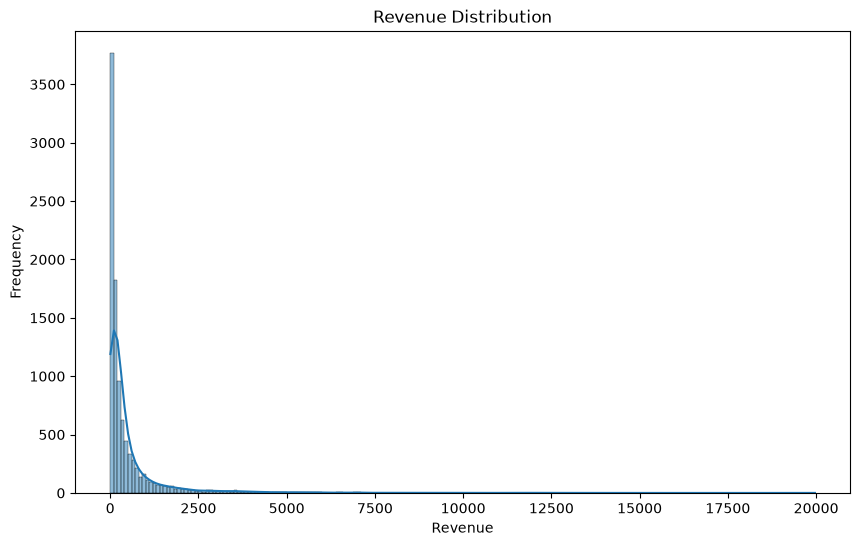

In [16]:
# Revenue Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Revenue",
    kde=True
)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

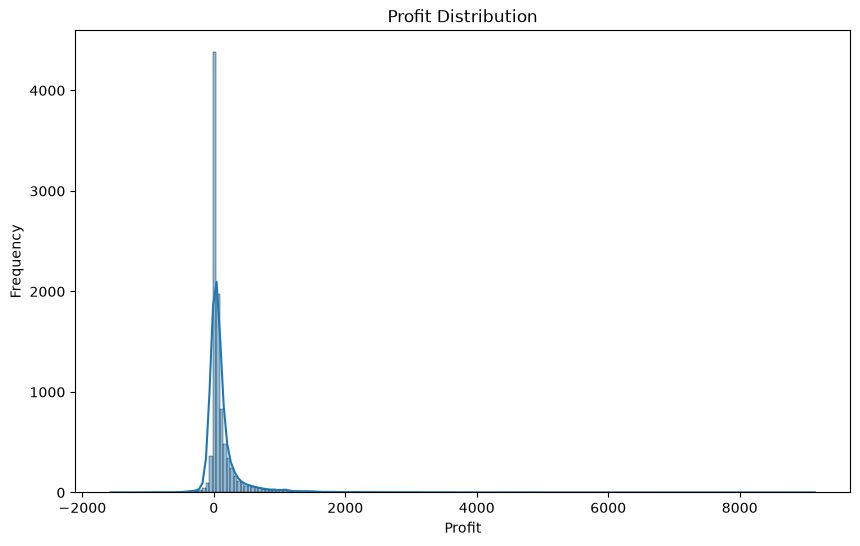

In [17]:
# Profit Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Profit",
    kde=True
)

plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

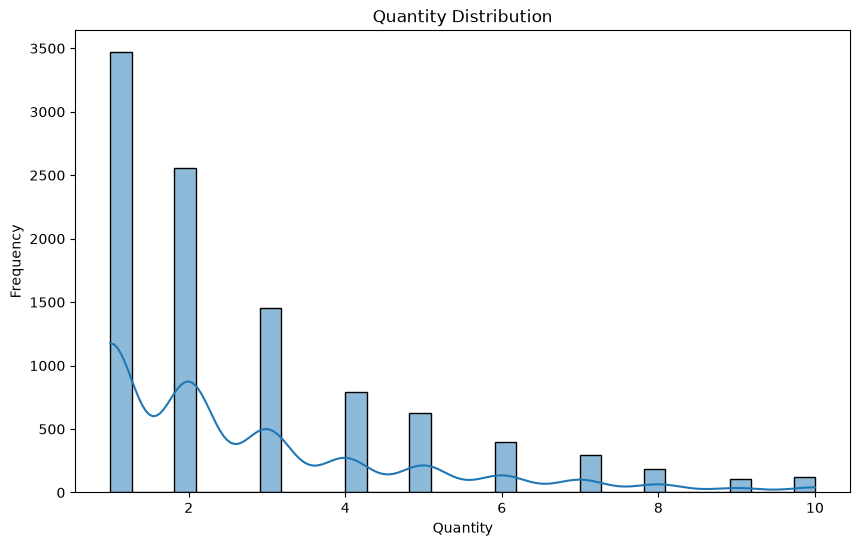

In [18]:
# Quantity Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Quantity",
    kde=True
)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

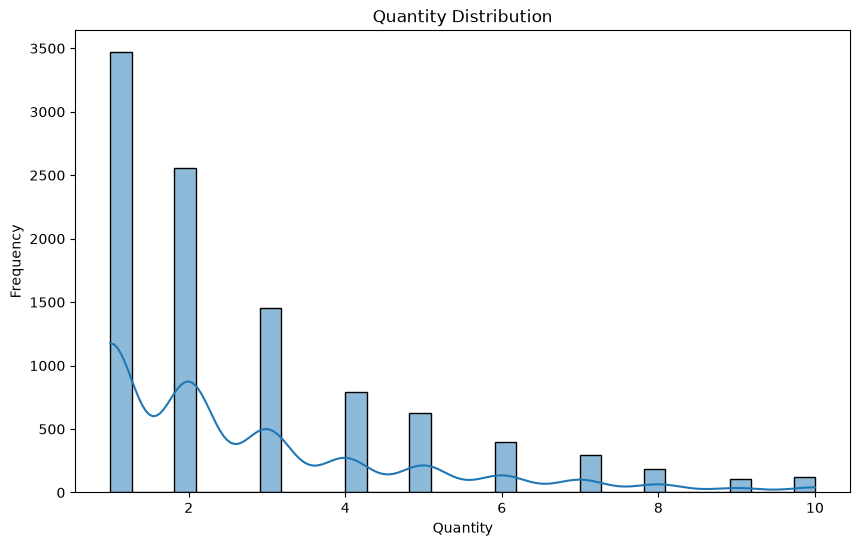

In [19]:
# Quantity Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Quantity",
    kde=True
)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

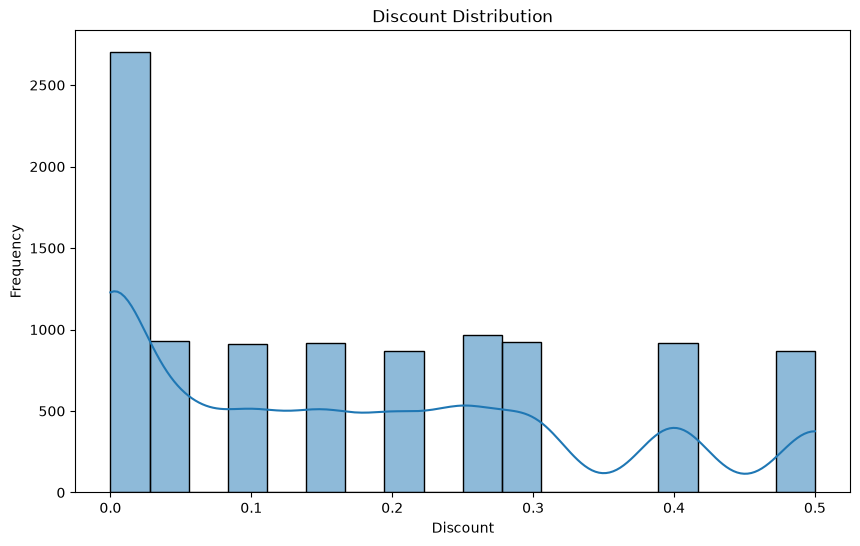

In [20]:
# Discount Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Discount",
    kde=True
)

plt.title("Discount Distribution")
plt.xlabel("Discount")
plt.ylabel("Frequency")
plt.show()

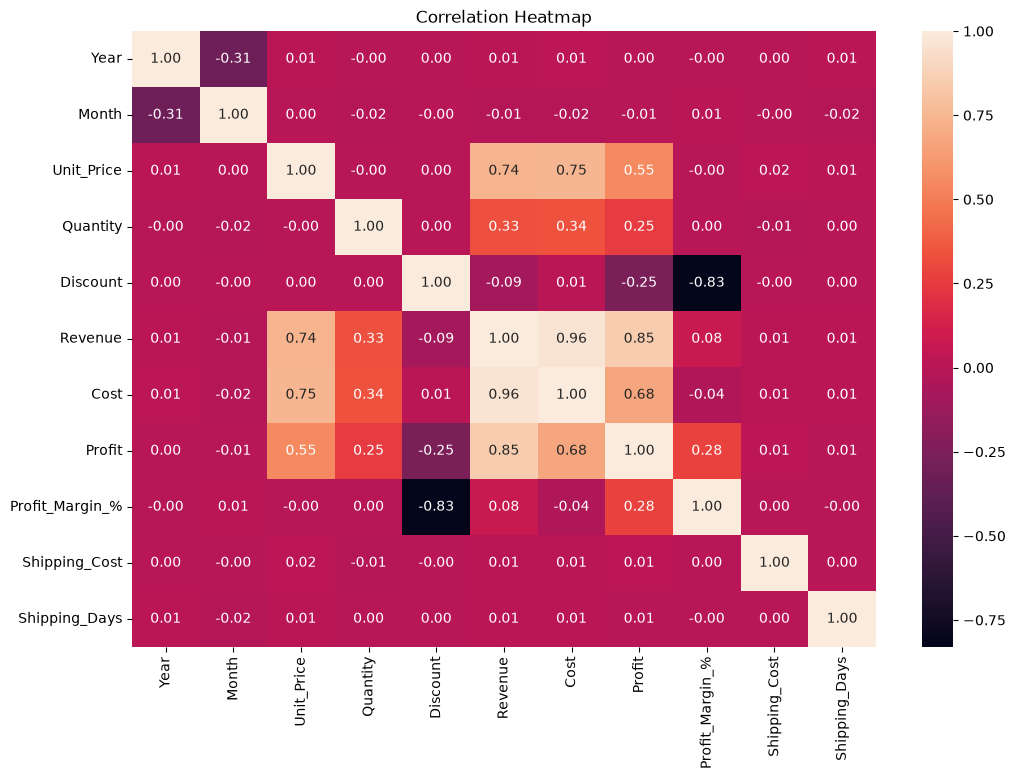

In [21]:
# Correlation Heatmap

correlation = df.select_dtypes(
    include=np.number
).corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()